In [1]:
# Source - https://stackoverflow.com/a/5399339
# Posted by pv., modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-23, License - CC BY-SA 4.0

%load_ext autoreload
%autoreload 2

from compute import *
from data_prices import *
from earnings import *
import random as rd
import matplotlib.pyplot as plt
import os


In [2]:

rd.seed(123)
prices_db_path = '../../data/prices.db'
earnings_db_path = '../../data/earnings.db'
plots_path = '../plots/'
start="2010-01-01"
end="2026-06-20"

print(os.curdir)
with open('../../s&p600list.txt') as f:
    sp600_tickers = [k.strip() for k in f.read().replace("\'", "").replace("[", "").split(",\n")]

tickers = rd.choices(sp600_tickers, k=300)
# faisable aussi en concurentiel le fetching mais bref 

print(f'Now analyzing from {start} to {end} the following {len(tickers)} tickers (S&P600 SmallCaps) ; Compared with IJW')
print(', '.join(tickers))


.
Now analyzing from 2010-01-01 to 2026-06-20 the following 300 tickers (S&P600 SmallCaps) ; Compared with IJW
ALGT, ARR, HLIT, AZTA, UFPT, AGNT, LYFT, FDP, SXI, CARG, FHB, FELE, CXM, AAP, ICHR, ARR, MWA, ANIP, EVTC, INSW, UNFI, ASTH, BOOT, SCHL, ACMR, UPWK, MMSI, DGII, SRPT, RRR, FLO, SFBS, CPF, NBTB, LTC, SHOO, EVTC, HCC, RUN, LGND, PI, NXRT, PBI, TWO, KMX, PCRX, GNW, ADUS, REZI, CFFN, SLVM, USPH, PARR, CCOI, FG, GVA, AOSL, IRDM, MMSI, FG, CLSK, ASO, NSSC, ACA, FSS, CUBI, LW, PSMT, UPBD, NXRT, XPEL, WERN, NTCT, CVCO, KMT, CENTA, XPEL, INDV, REYN, AHCO, BLFS, CNR, DCOM, FSS, DORM, IBP, HTH, AZZ, AMR, FTRE, ASO, IART, ABM, LYFT, AOSL, PLUS, HFWA, WU, DFIN, KAI, RES, FFBC, FOXF, NXRT, WINA, TRNO, HSTM, PRLB, PFBC, GNL, CVI, APOG, TRIP, ALRM, LNC, LZ, BRC, OXM, UTI, SAFE, GTY, BHE, WOR, LMAT, NTCT, SFBS, GTES, AMR, BLFS, PCRX, FRPT, TMDX, RAMP, WSFS, PCRX, EPAM, SCL, ADNT, LNN, TMDX, LKFN, BMI, LAUR, MATW, GIII, UAA, FIBK, DORM, LEG, CON, FBK, HCC, VRRM, ARCB, CNXN, COHU, YOU, UA, CNR, M

In [ ]:
# Init DBs

init_prices_db(prices_db_path)
init_earnings_db(earnings_db_path)

# Fetching all and storing into DBs

market_df = fetch_prices(['IJR'], start, end)
market_df.date = market_df.date.dt.tz_localize(None).astype('datetime64[us]')

prices_df = fetch_prices(tickers, start, end)

store_prices(prices_df, prices_db_path)

earnings_df = fetch_earnings(tickers)

earnings_df = compute_sue(earnings_df)

store_earnings(earnings_df, earnings_db_path)


# Storing also to parquet files

earnings_df.to_parquet('../../data/earnings.parquet')
prices_df.to_parquet('../../data/prices.parquet')
market_df.to_parquet('../../data/market_df.parquet')


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Fetching for ALGT...
Fetching for ARR...
Fetching for HLIT...
Fetching for AZTA...
Fetching for UFPT...
Fetching for AGNT...
Fetching for LYFT...
Fetching for FDP...
Fetching for SXI...
Fetching for CARG...
Fetching for FHB...
Fetching for FELE...
Fetching for CXM...
Fetching for AAP...
Fetching for ICHR...
Fetching for ARR...
Fetching for MWA...
Fetching for ANIP...
Fetching for EVTC...
Fetching for INSW...
Fetching for UNFI...
Fetching for ASTH...
Fetching for BOOT...
Fetching for SCHL...
Fetching for ACMR...
Fetching for UPWK...
Fetching for MMSI...
Fetching for DGII...
Fetching for SRPT...
Fetching for RRR...
Fetching for FLO...
Fetching for SFBS...
Fetching for CPF...
Fetching for NBTB...
Fetching for LTC...
Fetching for SHOO...
Fetching for EVTC...
Fetching for HCC...
Fetching for RUN...
Fetching for LGND...
Fetching for PI...
Fetching for NXRT...
Fetching for PBI...
Fetching for TWO...
Fetching for KMX...
Fetching for PCRX...
Fetching for GNW...
Fetching for ADUS...
Fetching for

VGNT: No earnings dates found, symbol may be delisted


Error for ticker VGNT: 'NoneType' object has no attribute 'reset_index'
Fetching for SHOO...
Fetching for LXP...
Fetching for SBH...
Fetching for KMT...
Fetching for PTON...
Fetching for SAFE...
Fetching for DCOM...
Fetching for SPHR...
Fetching for MOH...
Fetching for KMX...
Fetching for HAYW...
Fetching for CSW...
Fetching for LAUR...
Fetching for BGC...
Fetching for NWN...
Fetching for UE...
Fetching for SCHL...
Fetching for NBTB...
Fetching for KSS...
Fetching for PLXS...
Fetching for BFH...
Fetching for ALGT...
Fetching for TDW...
Fetching for FWRD...
Fetching for PCRX...
Fetching for HTH...
Fetching for FULT...
Fetching for RUN...
Fetching for FLO...
Fetching for REX...
Fetching for SLVM...
Fetching for CERT...
Fetching for WS...
Fetching for AMR...
Fetching for HOPE...
Fetching for LAUR...
Fetching for SNEX...
Fetching for CENT...
Fetching for MDU...
Fetching for GFF...
Fetching for VAC...
Fetching for BFH...
Fetching for DGII...
Fetching for SLVM...
Fetching for FBK...
Fetching

In [3]:
# option : load from parquet for faster

earnings_df = pd.read_parquet('../../data/earnings.parquet')
prices_df = pd.read_parquet('../../data/prices.parquet')
market_df = pd.read_parquet('../../data/market_df.parquet')

In [4]:
#compute returns

returns = compute_all_returns(earnings_df, prices_df, market_df, entry_offset=1)

In [68]:
# Testing if fetching from db works well

market_df2 = market_df.copy()

prices_df2 = load_prices(prices_db_path)
earnings_df2 = load_earnings(earnings_db_path)

returns2 = compute_all_returns(earnings_df2, prices_df2, market_df2)

In [76]:
print(f'{prices_df.shape[0]} vs {prices_df2.shape[0]}')
print(f'{earnings_df.shape[0]} vs {earnings_df2.shape[0]}')
print(f'{market_df.shape[0]} vs {market_df2.shape[0]}')
print(f'{returns.shape[0]} vs {returns2.shape[0]}')

804186 vs 804186
15660 vs 15660
4140 vs 4140
11568 vs 11253


In [77]:
returns.loc[returns.sue == np.inf]

,announcement,expected_eps,realized_eps,is_future,ticker,last_updated,surprise,sue,excess_return,sue_decile


In [78]:
returns['sue_decile'] = pd.qcut(returns.sue, 10)

In [79]:
returns = returns.loc[returns.sue != np.inf]

[]

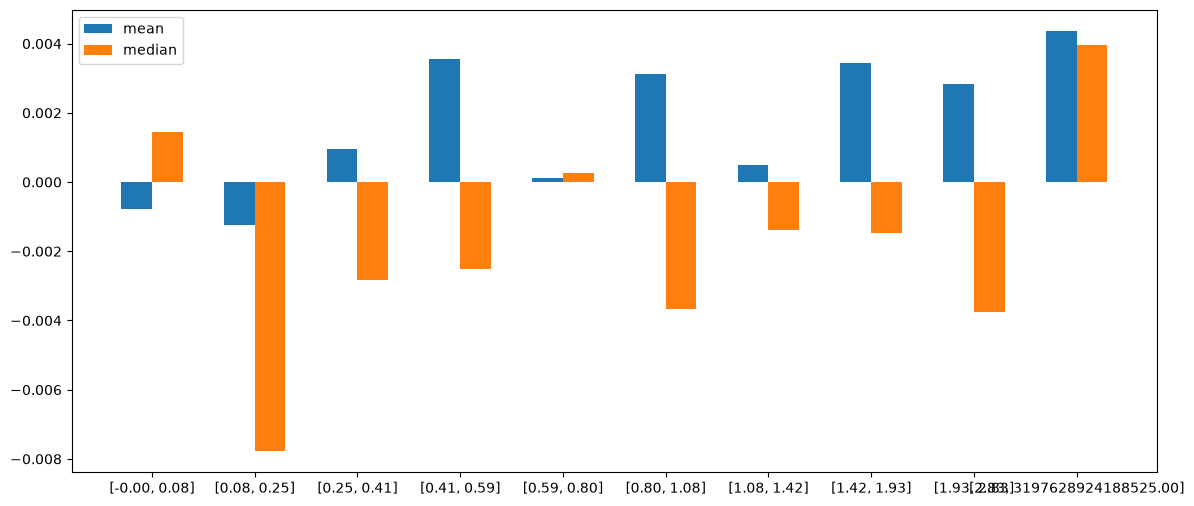

In [7]:
# Plot results
returns.sue = abs(returns.sue)
returns['sue_decile'] = pd.qcut(returns.sue, 10)
means = returns.groupby('sue_decile').excess_return.mean()
medians = returns.groupby('sue_decile').excess_return.median()


fig, ax = plt.subplots(figsize=(14,6))

ind = np.arange(10)
width = 0.3

ax.bar(ind - 0.15, means, width=0.3, label='mean')
ax.bar(ind + 0.15, medians, width=0.3, label='median')
ax.set_xticks(ind, labels=[f'[{k.left:.2f}, {k.right:.2f}]' for k in means.index])
ax.legend()
ax.plot()



Text(0.5, 1.0, 'Winsorized')

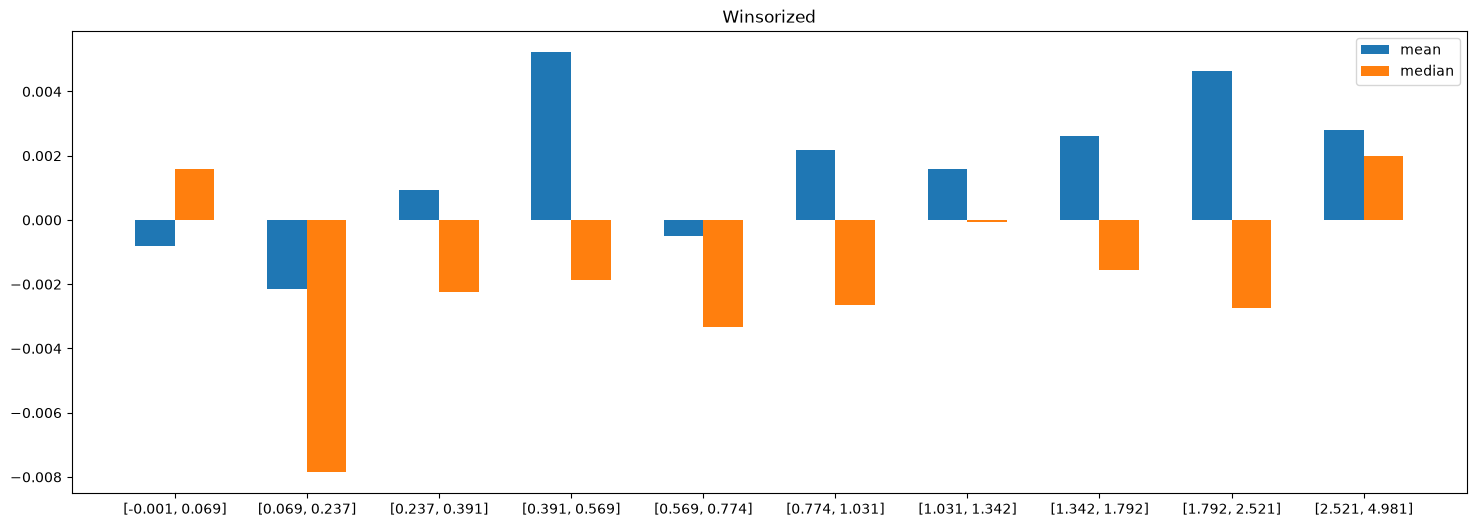

In [8]:
# WInsorization

returns2 = returns.copy()
returns2 = returns2.loc[abs(returns2.sue) <= 5]

returns2['sue_decile'] = pd.qcut(returns2.sue, 10)

means2 = returns2.groupby('sue_decile').excess_return.mean()
medians2 = returns2.groupby('sue_decile').excess_return.median()


fig, ax = plt.subplots(figsize=(18,6))

ind = np.arange(10)
width = 0.3

ax.bar(ind - 0.15, means2, width=0.3, label='mean')
ax.bar(ind + 0.15, medians2, width=0.3, label='median')
ax.set_xticks(ind, labels=[f'[{k.left:.3f}, {k.right:.3f}]' for k in means2.index])
ax.legend()
ax.plot()
ax.set_title('Winsorized')


# Quality filter : 

In [82]:
returns

,announcement,expected_eps,realized_eps,is_future,ticker,last_updated,surprise,sue,excess_return,sue_decile
66,2010-02-17,0.46,0.39,False,AAP,2026-06-26,-0.07,-1.429334,0.002716,"(-82.94, -1.079]"
65,2010-05-19,0.99,1.19,False,AAP,2026-06-26,0.20,3.380617,0.031011,"(2.437, 3197628924188525.0]"
64,2010-08-11,1.03,1.16,False,AAP,2026-06-26,0.13,1.641105,-0.003030,"(1.559, 2.437]"
63,2010-11-10,0.92,1.03,False,AAP,2026-06-26,0.11,1.324845,-0.016367,"(1.061, 1.559]"
62,2011-02-09,0.54,0.57,False,AAP,2026-06-26,0.03,0.363178,0.035301,"(0.148, 0.408]"
...,...,...,...,...,...,...,...,...,...,...
5,2025-05-08,1.25,1.14,False,ZD,2026-06-26,-0.11,-1.552002,-0.036875,"(-82.94, -1.079]"
4,2025-08-06,1.19,1.24,False,ZD,2026-06-26,0.05,0.603023,-0.019958,"(0.408, 0.692]"
3,2025-11-06,1.78,1.76,False,ZD,2026-06-26,-0.02,-0.239501,0.081405,"(-0.378, 0.0]"
2,2026-02-23,2.70,2.56,False,ZD,2026-06-26,-0.14,-1.686166,0.666384,"(-82.94, -1.079]"


In [83]:
prices_df

Price,date,adj_close,close,high,low,open,volume,ticker
0,2010-01-04,38.886906,48.009998,48.090000,47.169998,47.180000,253000,ALGT
1,2010-01-05,40.239571,49.680000,49.799999,47.799999,47.799999,434500,ALGT
2,2010-01-06,40.296268,49.750000,50.000000,49.500000,49.500000,362700,ALGT
3,2010-01-07,40.182869,49.610001,50.330002,49.240002,49.709999,224300,ALGT
4,2010-01-08,39.721188,49.040001,49.630001,48.759998,49.360001,379200,ALGT
...,...,...,...,...,...,...,...,...
1024042,2026-06-12,116.269997,116.269997,116.550003,114.639999,115.320000,165100,BANF
1024043,2026-06-15,113.400002,113.400002,117.500000,113.320000,116.550003,147800,BANF
1024044,2026-06-16,114.010002,114.010002,115.959999,113.589996,114.599998,194600,BANF
1024045,2026-06-17,110.669998,110.669998,115.660004,109.650002,113.510002,292800,BANF
